# Mean-Variance Optimization (MVO) Notebook

This notebook combines the uploaded mean-variance method and two static examples into one Python workflow:

1. **Theory**: portfolio return, portfolio variance, efficient frontier, Sharpe ratio, risk-free asset, and CAPM.
2. **Static examples**: a 3-asset example and an 8-asset allocation example using embedded data.
3. **Real-world portfolio case**: your current portfolio tickers with price data from `yfinance`.

> Educational use only. This is not financial advice. Mean-variance optimization is highly sensitive to expected-return assumptions, so use the output as a decision-support tool, not as an automatic trading signal.


## 1. Core idea from the mean-variance method

For a portfolio weight vector $x$, portfolio expected return and portfolio variance are:

$$
\mu_x = x^T \mu
$$

$$
\sigma_x^2 = x^T V x
$$

where:

- $x_i$ = portfolio weight in asset $i$
- $\mu_i$ = expected net return of asset $i$
- $V$ = covariance matrix of asset returns
- $\sigma_x$ = portfolio volatility

The efficient frontier is the set of portfolios that gives the **maximum return for a given risk**, or equivalently the **minimum risk for a target return**.

The main optimization used in this notebook is:

$$
\min_x \; x^T V x
$$

subject to:

$$
x^T \mu = r
$$

$$
\mathbf{1}^T x = 1
$$

For the risk-free asset case, the Sharpe/tangency risky portfolio is:

$$
s^* =
\frac{V^{-1}(\mu - r_f\mathbf{1})}
{\mathbf{1}^T V^{-1}(\mu - r_f\mathbf{1})}
$$

The notebook also includes practical long-only constrained versions because unconstrained MVO can create extreme short positions.


In [1]:
# ============================================================
# 2. Environment setup
# ============================================================
# In Colab or a fresh environment, uncomment this line:
# !pip install yfinance scipy pandas numpy matplotlib openpyxl

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
# ============================================================
# 3. MVO utility functions
# ============================================================

def clean_weights(w, tol=1e-10):
    # Clean tiny numerical noise.
    w = np.asarray(w, dtype=float)
    w[np.abs(w) < tol] = 0.0
    return w


def portfolio_return(w, mu):
    # Expected portfolio return in decimal units.
    return float(np.dot(w, mu))


def portfolio_variance(w, cov):
    # Portfolio variance in decimal squared units.
    return float(np.dot(w, cov @ w))


def portfolio_volatility(w, cov):
    # Portfolio volatility in decimal units.
    var = portfolio_variance(w, cov)
    return float(np.sqrt(max(var, 0.0)))


def portfolio_sharpe(w, mu, cov, rf=0.0):
    # Annualized Sharpe ratio using annualized inputs.
    vol = portfolio_volatility(w, cov)
    if vol <= 1e-12:
        return np.nan
    return (portfolio_return(w, mu) - rf) / vol


def metrics_row(name, w, mu, cov, rf=0.0):
    return {
        "Portfolio": name,
        "Return": portfolio_return(w, mu),
        "Volatility": portfolio_volatility(w, cov),
        "Variance": portfolio_variance(w, cov),
        "Sharpe": portfolio_sharpe(w, mu, cov, rf),
    }


def format_pct_table(df, pct_cols=("Return", "Volatility")):
    # Pretty display helper.
    out = df.copy()
    for c in pct_cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: f"{x:.2%}" if pd.notnull(x) else "")
    if "Sharpe" in out.columns:
        out["Sharpe"] = out["Sharpe"].map(lambda x: f"{x:.3f}" if pd.notnull(x) else "")
    if "Variance" in out.columns:
        out["Variance"] = out["Variance"].map(lambda x: f"{x:.6f}" if pd.notnull(x) else "")
    return out


def global_min_var_unconstrained(cov):
    # Unconstrained global minimum variance portfolio: V^-1 1 / (1^T V^-1 1).
    n = cov.shape[0]
    ones = np.ones(n)
    inv_cov = np.linalg.pinv(cov)
    w = inv_cov @ ones
    w = w / (ones @ inv_cov @ ones)
    return clean_weights(w)


def global_min_var_long_only(cov, max_weight=1.0):
    # Long-only global minimum variance portfolio.
    n = cov.shape[0]
    x0 = np.repeat(1 / n, n)
    bounds = [(0.0, max_weight)] * n
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    res = minimize(lambda w: portfolio_variance(w, cov), x0=x0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 2000, "ftol": 1e-12})
    if not res.success:
        raise RuntimeError(res.message)
    return clean_weights(res.x)


def min_var_weights_for_target_unconstrained(mu, cov, target_return):
    # Solve the Lagrangian/KKT system from the course notes:
    # minimize x^T V x subject to x^T mu = target_return and 1^T x = 1.
    # Shorting is allowed in this version.
    mu = np.asarray(mu, dtype=float)
    cov = np.asarray(cov, dtype=float)
    n = len(mu)
    ones = np.ones(n)

    A = np.zeros((n + 2, n + 2))
    A[:n, :n] = 2 * cov
    A[:n, n] = -mu
    A[:n, n + 1] = -ones
    A[n, :n] = mu
    A[n + 1, :n] = ones

    b = np.zeros(n + 2)
    b[n] = target_return
    b[n + 1] = 1.0

    try:
        sol = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        sol = np.linalg.lstsq(A, b, rcond=None)[0]
    return clean_weights(sol[:n])


def min_var_weights_for_target_long_only(mu, cov, target_return, max_weight=1.0, x0=None):
    # Long-only min variance portfolio for target return.
    mu = np.asarray(mu, dtype=float)
    cov = np.asarray(cov, dtype=float)
    n = len(mu)
    if x0 is None:
        x0 = np.repeat(1 / n, n)
    bounds = [(0.0, max_weight)] * n
    cons = (
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "eq", "fun": lambda w: np.dot(w, mu) - target_return},
    )
    res = minimize(lambda w: portfolio_variance(w, cov), x0=x0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 2000, "ftol": 1e-12})
    if not res.success:
        return None
    return clean_weights(res.x)


def efficient_frontier_unconstrained(mu, cov, target_returns):
    rows = []
    weights = []
    for r in target_returns:
        w = min_var_weights_for_target_unconstrained(mu, cov, r)
        weights.append(w)
        rows.append(metrics_row("unconstrained", w, mu, cov))
    out = pd.DataFrame(rows)
    out["Target Return"] = target_returns
    return out, np.array(weights)


def efficient_frontier_long_only(mu, cov, target_returns, max_weight=1.0):
    rows = []
    weights = []
    x0 = None
    for r in target_returns:
        w = min_var_weights_for_target_long_only(mu, cov, r, max_weight=max_weight, x0=x0)
        if w is None:
            continue
        x0 = w
        weights.append(w)
        rows.append(metrics_row("long_only", w, mu, cov))
    if not rows:
        return pd.DataFrame(), np.array([])
    out = pd.DataFrame(rows)
    return out, np.array(weights)


def max_sharpe_unconstrained(mu, cov, rf=0.0):
    # Risky tangency portfolio with a risk-free asset:
    # s* = V^-1(mu-rf*1) / 1^T V^-1(mu-rf*1).
    # Shorting is allowed.
    mu = np.asarray(mu, dtype=float)
    cov = np.asarray(cov, dtype=float)
    ones = np.ones(len(mu))
    inv_cov = np.linalg.pinv(cov)
    excess = mu - rf * ones
    raw = inv_cov @ excess
    denom = ones @ raw
    if abs(denom) <= 1e-12:
        return None
    return clean_weights(raw / denom)


def max_sharpe_long_only(mu, cov, rf=0.0, max_weight=1.0):
    # Long-only maximum Sharpe portfolio.
    n = len(mu)
    x0 = np.repeat(1 / n, n)
    bounds = [(0.0, max_weight)] * n
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)

    def neg_sharpe(w):
        s = portfolio_sharpe(w, mu, cov, rf)
        if np.isnan(s):
            return 1e9
        return -s

    res = minimize(neg_sharpe, x0=x0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 2000, "ftol": 1e-12})
    if not res.success:
        raise RuntimeError(res.message)
    return clean_weights(res.x)


def risk_adjusted_long_only(mu, cov, tau=1.0, max_weight=1.0):
    # Maximize risk-adjusted return: mu^T x - tau*x^T V x.
    n = len(mu)
    x0 = np.repeat(1 / n, n)
    bounds = [(0.0, max_weight)] * n
    cons = ({"type": "eq", "fun": lambda w: np.sum(w) - 1.0},)
    obj = lambda w: -(portfolio_return(w, mu) - tau * portfolio_variance(w, cov))
    res = minimize(obj, x0=x0, method="SLSQP", bounds=bounds, constraints=cons,
                   options={"maxiter": 2000, "ftol": 1e-12})
    if not res.success:
        raise RuntimeError(res.message)
    return clean_weights(res.x)


def random_long_only_portfolios(mu, cov, n_portfolios=5000, rf=0.0, max_weight=1.0, seed=42):
    # Monte Carlo long-only portfolios. Rejection sampling handles optional max weight caps.
    local_rng = np.random.default_rng(seed)
    n = len(mu)
    draws = []
    tries = 0
    batch = max(2000, n_portfolios)
    while len(draws) < n_portfolios and tries < 100:
        w = local_rng.dirichlet(np.ones(n), size=batch)
        if max_weight < 1.0:
            w = w[(w <= max_weight + 1e-12).all(axis=1)]
        if len(w) > 0:
            draws.append(w)
        tries += 1
    if len(draws) == 0:
        weights = local_rng.dirichlet(np.ones(n), size=n_portfolios)
    else:
        weights = np.vstack(draws)[:n_portfolios]
    rets = weights @ mu
    vols = np.sqrt(np.einsum("ij,jk,ik->i", weights, cov, weights))
    sharpes = (rets - rf) / np.where(vols == 0, np.nan, vols)
    return pd.DataFrame({"Return": rets, "Volatility": vols, "Sharpe": sharpes}), weights


def plot_weights(weight_dict, asset_names, title="Portfolio weights"):
    df = pd.DataFrame(weight_dict, index=asset_names)
    ax = df.plot(kind="bar", figsize=(11, 5))
    ax.set_title(title)
    ax.set_ylabel("Weight")
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.axhline(0, linewidth=1)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return df


def plot_corr_heatmap(returns, title="Correlation matrix"):
    corr = returns.corr()
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(corr.values, vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()
    return corr


def plot_efficient_frontier(mu, cov, asset_names, rf=0.0, current_weights=None, current_name="Current", 
                            title="Efficient frontier", n_random=5000, max_weight=1.0):
    mu = np.asarray(mu, dtype=float)
    cov = np.asarray(cov, dtype=float)
    asset_names = list(asset_names)

    # Random long-only cloud
    random_df, random_w = random_long_only_portfolios(mu, cov, n_random, rf=rf, max_weight=max_weight, seed=RANDOM_SEED)

    # Long-only frontier: target return range feasible by long-only single assets.
    targets_lo = np.linspace(mu.min(), mu.max(), 80)
    frontier_lo, weights_lo = efficient_frontier_long_only(mu, cov, targets_lo, max_weight=max_weight)

    # Unconstrained frontier: wider target range to show shorting/leverage effect.
    ret_range = mu.max() - mu.min()
    low = mu.min() - 0.25 * ret_range
    high = mu.max() + 0.75 * ret_range
    targets_un = np.linspace(low, high, 120)
    frontier_un, weights_un = efficient_frontier_unconstrained(mu, cov, targets_un)

    # Key portfolios
    w_gmv_lo = global_min_var_long_only(cov, max_weight=max_weight)
    w_sharpe_lo = max_sharpe_long_only(mu, cov, rf=rf, max_weight=max_weight)
    w_gmv_un = global_min_var_unconstrained(cov)
    w_sharpe_un = max_sharpe_unconstrained(mu, cov, rf=rf)
    w_utility = risk_adjusted_long_only(mu, cov, tau=1.0, max_weight=max_weight)

    key_rows = [
        metrics_row("GMV long-only", w_gmv_lo, mu, cov, rf),
        metrics_row("Max Sharpe long-only", w_sharpe_lo, mu, cov, rf),
        metrics_row("Risk-adjusted tau=1", w_utility, mu, cov, rf),
        metrics_row("GMV unconstrained", w_gmv_un, mu, cov, rf),
    ]
    if w_sharpe_un is not None:
        key_rows.append(metrics_row("Max Sharpe unconstrained", w_sharpe_un, mu, cov, rf))

    if current_weights is not None:
        current_weights = np.asarray(current_weights, dtype=float)
        current_weights = current_weights / current_weights.sum()
        key_rows.insert(0, metrics_row(current_name, current_weights, mu, cov, rf))

    key_df = pd.DataFrame(key_rows)

    # Plot frontier
    fig, ax = plt.subplots(figsize=(11, 7))
    sc = ax.scatter(random_df["Volatility"] * 100, random_df["Return"] * 100, 
                    c=random_df["Sharpe"], s=10, alpha=0.35)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Sharpe ratio")

    if not frontier_lo.empty:
        ax.plot(frontier_lo["Volatility"] * 100, frontier_lo["Return"] * 100, linewidth=3, label="Efficient frontier, long-only")
    ax.plot(frontier_un["Volatility"] * 100, frontier_un["Return"] * 100, linestyle="--", linewidth=2, label="Frontier, shorting allowed")

    # Plot individual assets
    asset_vols = np.sqrt(np.diag(cov))
    ax.scatter(asset_vols * 100, mu * 100, marker="x", s=80, label="Single assets")
    for i, name in enumerate(asset_names):
        ax.annotate(name, (asset_vols[i] * 100, mu[i] * 100), xytext=(5, 5), textcoords="offset points", fontsize=9)

    # Plot key portfolios
    def point(w, label, marker):
        ax.scatter(portfolio_volatility(w, cov) * 100, portfolio_return(w, mu) * 100, s=130, marker=marker, label=label)

    if current_weights is not None:
        point(current_weights, current_name, "*")
    point(w_gmv_lo, "GMV long-only", "D")
    point(w_sharpe_lo, "Max Sharpe long-only", "P")

    if rf is not None and portfolio_volatility(w_sharpe_lo, cov) > 1e-12:
        max_x = max(random_df["Volatility"].max(), frontier_un["Volatility"].max()) * 1.05
        cml_x = np.linspace(0, max_x, 100)
        cml_y = rf + portfolio_sharpe(w_sharpe_lo, mu, cov, rf) * cml_x
        ax.plot(cml_x * 100, cml_y * 100, linestyle=":", linewidth=2, label="Capital market line, long-only tangency")
        ax.scatter([0], [rf * 100], s=80, marker="o", label="Risk-free rate")

    ax.set_title(title)
    ax.set_xlabel("Volatility / risk (%)")
    ax.set_ylabel("Expected return (%)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # Weight comparison
    weight_map = {
        "GMV long-only": w_gmv_lo,
        "Max Sharpe long-only": w_sharpe_lo,
        "Risk-adjusted tau=1": w_utility,
    }
    if current_weights is not None:
        weight_map = {current_name: current_weights, **weight_map}

    weights_df = pd.DataFrame(weight_map, index=asset_names)
    return {
        "random": random_df,
        "frontier_long_only": frontier_lo,
        "frontier_unconstrained": frontier_un,
        "summary": key_df,
        "weights": weights_df,
        "weights_long_only_array": {
            "gmv": w_gmv_lo,
            "max_sharpe": w_sharpe_lo,
            "risk_adjusted_tau_1": w_utility,
        },
        "weights_unconstrained_array": {
            "gmv": w_gmv_un,
            "max_sharpe": w_sharpe_un,
        }
    }

## 4. Static example 1: 3-asset mean-variance model

The first static example contains:

- 3 assets
- Mean returns: 6%, 2%, 4%
- Risk-free rate: 1%
- A 3x3 covariance matrix

This is a clean example for understanding how covariance affects portfolio risk.


,Asset,Expected return,Volatility
0,Asset 1,6.00%,8.94%
1,Asset 2,2.00%,4.47%
2,Asset 3,4.00%,8.94%


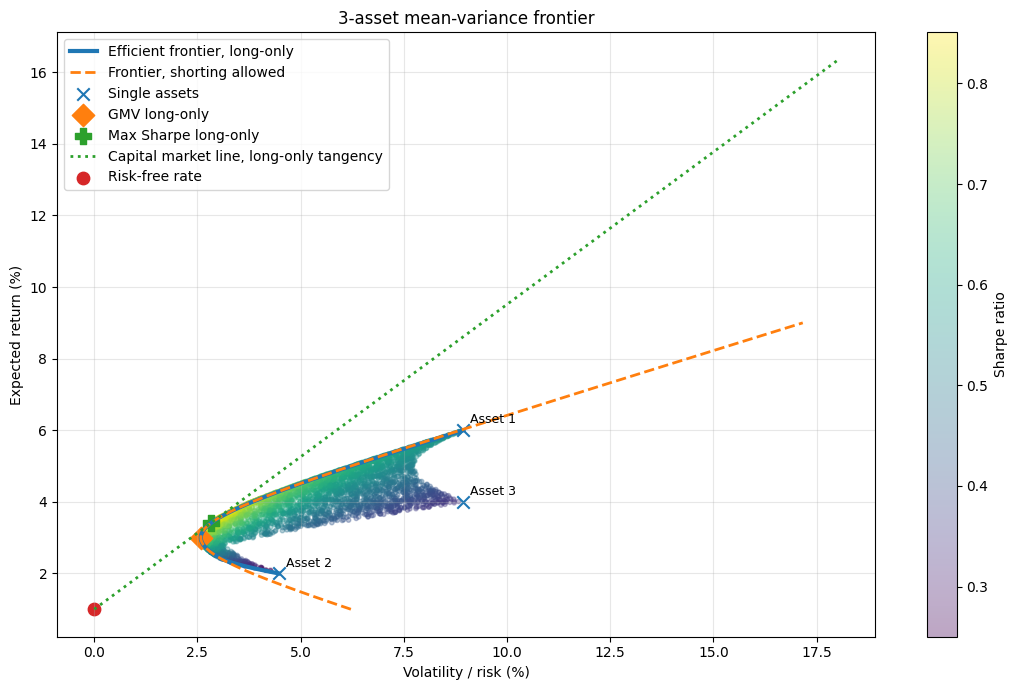

,Portfolio,Return,Volatility,Variance,Sharpe
0,GMV long-only,3.00%,2.58%,0.000667,0.775
1,Max Sharpe long-only,3.42%,2.84%,0.000806,0.851
2,Risk-adjusted tau=1,6.00%,8.94%,0.008000,0.559
3,GMV unconstrained,3.00%,2.58%,0.000667,0.775
4,Max Sharpe unconstrained,3.42%,2.84%,0.000806,0.851


,GMV long-only,Max Sharpe long-only,Risk-adjusted tau=1
Asset 1,16.67%,29.17%,100.00%
Asset 2,66.67%,58.33%,0.00%
Asset 3,16.67%,12.50%,0.00%


In [5]:
# ============================================================
# 4.1 Embedded data for the 3-asset example
# ============================================================
assignment_asset_names = ["Asset 1", "Asset 2", "Asset 3"]
assignment_mu = np.array([6, 2, 4], dtype=float) / 100  # percent -> decimal
assignment_cov = np.array([
    [ 0.008, -0.002,  0.004],
    [-0.002,  0.002, -0.002],
    [ 0.004, -0.002,  0.008],
], dtype=float)
assignment_rf = 0.01

asset_table = pd.DataFrame({
    "Asset": assignment_asset_names,
    "Expected return": assignment_mu,
    "Volatility": np.sqrt(np.diag(assignment_cov)),
})
display(format_pct_table(asset_table, pct_cols=("Expected return", "Volatility")))

assignment_results = plot_efficient_frontier(
    assignment_mu, assignment_cov, assignment_asset_names, 
    rf=assignment_rf,
    title="3-asset mean-variance frontier",
    n_random=4000,
    max_weight=1.0,
)

display(format_pct_table(assignment_results["summary"]))
display(assignment_results["weights"].map(lambda x: f"{x:.2%}"))

### How to read the 3-asset chart

- **Dots** are random long-only portfolios.
- The **frontier line** is the best return available for each level of risk.
- A point below the frontier is historically inefficient: another weight mix gives higher return for similar risk.
- The **unconstrained frontier** can look much better because it allows shorting and leverage-like behavior through negative weights. This is mathematically useful but often unrealistic for a normal personal portfolio.


## 5. Static example 2: 8-asset allocation model

The second static example contains 8 asset classes:

1. US Bonds
2. International Bonds
3. US Large Growth
4. US Large Value
5. US Small Growth
6. US Small Value
7. International Developed Equity
8. International Emerging Equity

Below, we reproduce the same mean-variance logic in Python.


,Asset,Expected return,Volatility
0,US Bonds,3.15%,3.17%
1,Int'l Bonds,1.75%,8.53%
2,US Large Growth,-6.39%,24.46%
3,US Large Value,-2.86%,17.21%
4,US Small Growth,-6.75%,32.01%
5,US Small Value,-0.54%,17.90%
6,Int'l Dev Equity,-6.75%,16.84%
7,Int'l Emerg Equity,-5.26%,28.28%


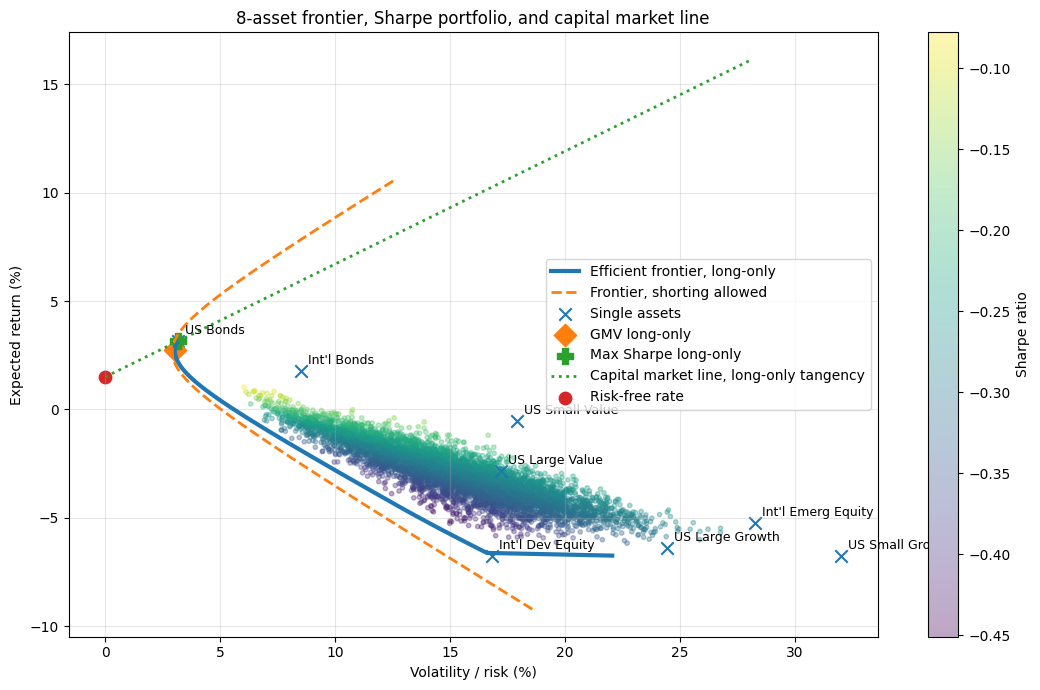

,Portfolio,Return,Volatility,Variance,Sharpe
0,GMV long-only,2.73%,3.02%,0.000912,0.408
1,Max Sharpe long-only,3.15%,3.17%,0.001005,0.520
2,Risk-adjusted tau=1,3.15%,3.17%,0.001005,0.520
3,GMV unconstrained,2.66%,2.91%,0.000848,0.397
4,Max Sharpe unconstrained,5.73%,5.56%,0.003097,0.760


,GMV long-only,Max Sharpe long-only,Risk-adjusted tau=1
US Bonds,94.23%,100.00%,100.00%
Int'l Bonds,0.00%,0.00%,0.00%
US Large Growth,0.00%,0.00%,0.00%
US Large Value,3.97%,0.00%,0.00%
US Small Growth,0.00%,0.00%,0.00%
US Small Value,0.00%,0.00%,0.00%
Int'l Dev Equity,1.79%,0.00%,0.00%
Int'l Emerg Equity,0.00%,0.00%,0.00%


In [6]:
# ============================================================
# 5.1 Embedded data for the 8-asset example
# ============================================================
mvo_asset_names = [
    "US Bonds", "Int'l Bonds", "US Large Growth", "US Large Value", 
    "US Small Growth", "US Small Value", "Int'l Dev Equity", "Int'l Emerg Equity"
]

mvo_mu = np.array([3.15, 1.75, -6.39, -2.86, -6.75, -0.54, -6.75, -5.26], dtype=float) / 100

mvo_cov = np.array([
    [ 0.001005,  0.001328, -0.000579, -0.000675,  0.000121,  0.000128, -0.000445, -0.000437],
    [ 0.001328,  0.007277, -0.001307, -0.000610, -0.002237, -0.000989,  0.001442, -0.001535],
    [-0.000579, -0.001307,  0.059852,  0.027588,  0.063497,  0.023036,  0.032967,  0.048039],
    [-0.000675, -0.000610,  0.027588,  0.029609,  0.026572,  0.021465,  0.020697,  0.029854],
    [ 0.000121, -0.002237,  0.063497,  0.026572,  0.102488,  0.042744,  0.039943,  0.065994],
    [ 0.000128, -0.000989,  0.023036,  0.021465,  0.042744,  0.032056,  0.019881,  0.032235],
    [-0.000445,  0.001442,  0.032967,  0.020697,  0.039943,  0.019881,  0.028355,  0.035064],
    [-0.000437, -0.001535,  0.048039,  0.029854,  0.065994,  0.032235,  0.035064,  0.079958],
], dtype=float)

mvo_rf = 0.015

mvo_asset_table = pd.DataFrame({
    "Asset": mvo_asset_names,
    "Expected return": mvo_mu,
    "Volatility": np.sqrt(np.diag(mvo_cov)),
})
display(format_pct_table(mvo_asset_table, pct_cols=("Expected return", "Volatility")))

mvo_results = plot_efficient_frontier(
    mvo_mu, mvo_cov, mvo_asset_names,
    rf=mvo_rf,
    title="8-asset frontier, Sharpe portfolio, and capital market line",
    n_random=6000,
    max_weight=1.0,
)

display(format_pct_table(mvo_results["summary"]))
display(mvo_results["weights"].map(lambda x: f"{x:.2%}"))

### Important interpretation for the 8-asset example

The sample mean returns are negative for several equity classes. Because MVO trusts the historical mean estimates directly, it may allocate heavily to bonds or even create extreme short positions in the unconstrained version.

This is not a bug. It is a core weakness of naive mean-variance optimization:

- mean return estimates are noisy;
- covariance estimates are more stable than means, but still sample-dependent;
- allowing shorts can create extreme solutions;
- constraints often matter more than the mathematical optimum.

For real portfolios, prefer practical constraints such as long-only, max position size, no shorting, and maybe a minimum allocation to cash or short-term Treasury ETFs.


## 6. Real-world case: your portfolio using `yfinance`

Your portfolio list from the prompt:

| Ticker | Approx. weight | Amount |
|---|---:|---:|
| SGOV | 20.06% | $1,406.45 |
| SCHD | 19.63% | $1,376.23 |
| KO | 14.77% | $1,035.72 |
| ABBV | 14.02% | $982.70 |
| AAPL | 8.00% | $561.76 |
| O | 6.66% | $467.00 |
| JEPQ | 5.27% | $370.00 |
| COST | 3.00% | $210.00 |
| Other | about 8.59% | not specified |

Note: you typed `APPL`, but the Apple ticker is `AAPL`, so this notebook uses `AAPL`.

By default, the optimizer uses only the listed tickers with amounts. The `Other` bucket is excluded from optimization unless you assign it a ticker, cash assumption, or amount.

Listed amount total: $6,409.86
Prompt listed weights sum: 91.41%
Implied 'Other' weight from prompt: 8.59%


,Amount,"Weight from amount, normalized over listed tickers",Prompt weight
SGOV,"$1,406.45",21.94%,20.06%
SCHD,"$1,376.23",21.47%,19.63%
KO,"$1,035.72",16.16%,14.77%
ABBV,$982.70,15.33%,14.02%
AAPL,$561.76,8.76%,8.00%
O,$467.00,7.29%,6.66%
JEPQ,$370.00,5.77%,5.27%
COST,$210.00,3.28%,3.00%


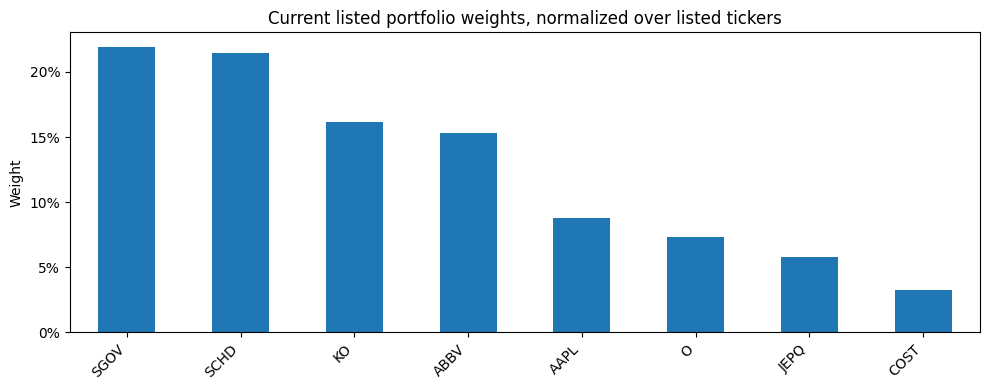

In [7]:
# ============================================================
# 6.1 Your real portfolio inputs
# ============================================================
# Edit this block anytime.

portfolio_amounts = {
    "SGOV": 1406.45,
    "SCHD": 1376.23,
    "KO": 1035.72,
    "ABBV": 982.70,
    "AAPL": 561.76,   # corrected from APPL -> AAPL
    "O": 467.00,
    "JEPQ": 370.00,
    "COST": 210.00,
}

portfolio_prompt_weights_pct = {
    "SGOV": 20.06,
    "SCHD": 19.63,
    "KO": 14.77,
    "ABBV": 14.02,
    "AAPL": 8.00,
    "O": 6.66,
    "JEPQ": 5.27,
    "COST": 3.00,
}

portfolio_amounts_s = pd.Series(portfolio_amounts, dtype=float)
current_weights_amount_based = portfolio_amounts_s / portfolio_amounts_s.sum()

prompt_weights_s = pd.Series(portfolio_prompt_weights_pct, dtype=float) / 100
other_weight = 1 - prompt_weights_s.sum()

print(f"Listed amount total: ${portfolio_amounts_s.sum():,.2f}")
print(f"Prompt listed weights sum: {prompt_weights_s.sum():.2%}")
print(f"Implied 'Other' weight from prompt: {other_weight:.2%}")

display(pd.DataFrame({
    "Amount": portfolio_amounts_s,
    "Weight from amount, normalized over listed tickers": current_weights_amount_based,
    "Prompt weight": prompt_weights_s,
}).style.format({"Amount": "${:,.2f}", "Weight from amount, normalized over listed tickers": "{:.2%}", "Prompt weight": "{:.2%}"}))

current_weights_amount_based.plot(kind="bar", figsize=(10, 4), title="Current listed portfolio weights, normalized over listed tickers")
plt.ylabel("Weight")
plt.gca().yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# 6.2 Download data from yfinance
# ============================================================
# This cell needs internet access. In ChatGPT's sandbox, internet may be disabled,
# but it should run in your local Jupyter/Colab environment.

USE_YFINANCE = True
START_DATE = "2023-01-01"  # JEPQ is relatively new; 2023 keeps all assets in the sample.
END_DATE = None             # None = today
RETURN_FREQ = "ME"          # Monthly end prices. Use "W-FRI" for weekly or keep "ME" for monthly.
PERIODS_PER_YEAR = 12       # Monthly = 12, weekly = 52, daily approx = 252
MAX_WEIGHT = 0.40           # Practical long-only cap. Set to 1.0 for no cap.
DEFAULT_RF_ANNUAL = 0.04    # Fallback annual risk-free rate if ^IRX cannot be downloaded.


def download_prices_yfinance(tickers, start=START_DATE, end=END_DATE):
    import yfinance as yf
    raw = yf.download(tickers, start=start, end=end, progress=False, auto_adjust=True)
    if raw.empty:
        raise ValueError("No data downloaded. Check ticker list, dates, or internet connection.")
    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" in raw.columns.get_level_values(0):
            prices = raw["Close"].copy()
        elif "Adj Close" in raw.columns.get_level_values(0):
            prices = raw["Adj Close"].copy()
        else:
            raise ValueError(f"Could not find Close/Adj Close columns. Columns: {raw.columns}")
    else:
        prices = raw.copy()
        if isinstance(prices, pd.Series):
            prices = prices.to_frame(tickers[0])
    prices = prices.dropna(axis=1, how="all")
    return prices


def get_rf_annual_from_yfinance(default_rf=DEFAULT_RF_ANNUAL):
    # Use ^IRX 13-week T-bill yield as a quick proxy.
    # ^IRX is quoted in percent, e.g. 5.2 means 5.2%.
    try:
        import yfinance as yf
        irx = yf.download("^IRX", period="10d", progress=False, auto_adjust=True)
        if irx.empty:
            return default_rf
        close = irx["Close"].dropna()
        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]
        return float(close.iloc[-1]) / 100
    except Exception as e:
        print(f"Could not download ^IRX risk-free rate. Using default {default_rf:.2%}. Error: {e}")
        return default_rf


def prices_to_returns(prices, freq=RETURN_FREQ):
    period_prices = prices.resample(freq).last()
    returns = period_prices.pct_change().dropna(how="all")
    returns = returns.dropna(axis=1, how="any")  # keep only assets with complete aligned history
    return returns


def annualize_return_and_cov(returns, periods_per_year=PERIODS_PER_YEAR):
    # Arithmetic annualized mean is aligned with the classic MVO framework.
    mu = returns.mean().values * periods_per_year
    cov = returns.cov().values * periods_per_year
    return mu, cov

if USE_YFINANCE:
    tickers = list(portfolio_amounts.keys())
    prices = download_prices_yfinance(tickers, start=START_DATE, end=END_DATE)
    returns = prices_to_returns(prices, freq=RETURN_FREQ)
    aligned_tickers = list(returns.columns)
    rf_annual = get_rf_annual_from_yfinance(DEFAULT_RF_ANNUAL)

    print("Downloaded tickers:", aligned_tickers)
    print(f"Date range used: {returns.index.min().date()} to {returns.index.max().date()}")
    print(f"Annual risk-free rate used: {rf_annual:.2%}")

    mu_real, cov_real = annualize_return_and_cov(returns, periods_per_year=PERIODS_PER_YEAR)

    # Align current weights to available tickers and renormalize.
    current_weights_real = current_weights_amount_based.reindex(aligned_tickers).dropna()
    current_weights_real = current_weights_real / current_weights_real.sum()

    display(pd.DataFrame({
        "Annualized expected return": mu_real,
        "Annualized volatility": np.sqrt(np.diag(cov_real)),
        "Current weight": current_weights_real.values,
    }, index=aligned_tickers).style.format("{:.2%}"))

    returns.tail()

Downloaded tickers: ['AAPL', 'ABBV', 'COST', 'JEPQ', 'KO', 'O', 'SCHD', 'SGOV']
Date range used: 2023-02-28 to 2026-08-31
Annual risk-free rate used: 3.68%


,Annualized expected return,Annualized volatility,Current weight
AAPL,24.63%,21.39%,8.76%
ABBV,21.39%,21.48%,15.33%
COST,19.95%,18.89%,3.28%
JEPQ,20.81%,11.20%,5.77%
KO,14.51%,15.33%,16.16%
O,4.48%,18.87%,7.29%
SCHD,12.97%,13.29%,21.47%
SGOV,4.56%,0.22%,21.94%


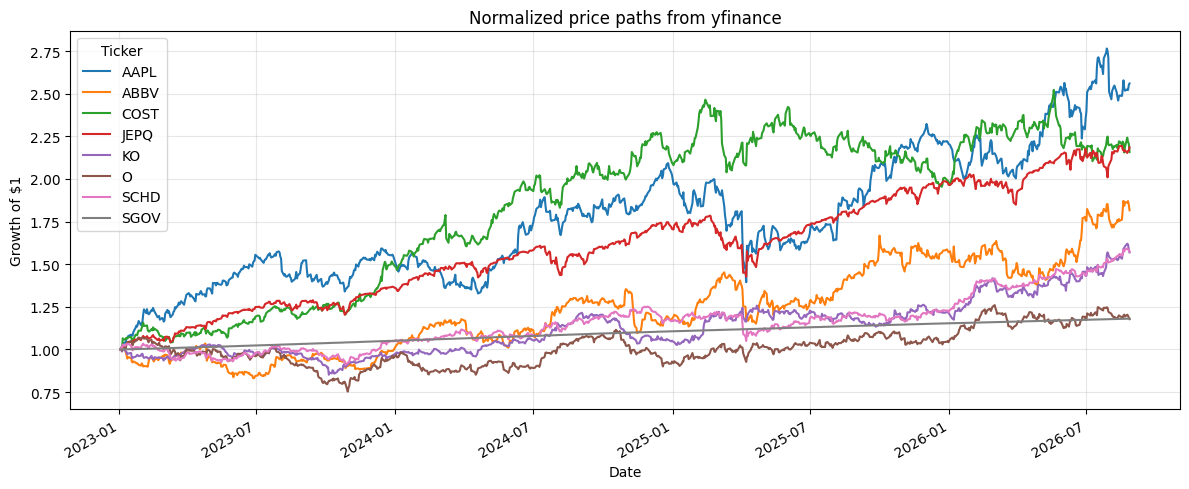

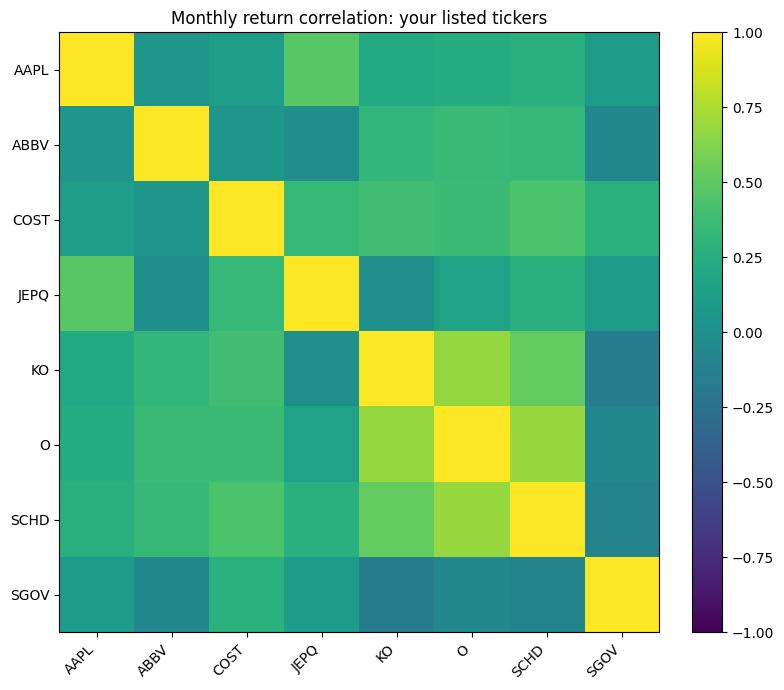

Ticker,AAPL,ABBV,COST,JEPQ,KO,O,SCHD,SGOV
Ticker,,,,,,,,
AAPL,1.00,0.05,0.12,0.48,0.22,0.24,0.25,0.10
ABBV,0.05,1.00,0.05,-0.00,0.32,0.35,0.33,-0.07
COST,0.12,0.05,1.00,0.34,0.38,0.36,0.43,0.28
JEPQ,0.48,-0.00,0.34,1.00,0.00,0.15,0.27,0.10
KO,0.22,0.32,0.38,0.00,1.00,0.69,0.52,-0.16
O,0.24,0.35,0.36,0.15,0.69,1.00,0.69,-0.07
SCHD,0.25,0.33,0.43,0.27,0.52,0.69,1.00,-0.10
SGOV,0.10,-0.07,0.28,0.10,-0.16,-0.07,-0.10,1.00


In [9]:
# ============================================================
# 6.3 Visualize historical prices and correlations
# ============================================================
if USE_YFINANCE:
    norm_prices = prices[aligned_tickers] / prices[aligned_tickers].iloc[0]
    ax = norm_prices.plot(figsize=(12, 5), title="Normalized price paths from yfinance")
    ax.set_ylabel("Growth of $1")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    corr = plot_corr_heatmap(returns[aligned_tickers], title="Monthly return correlation: your listed tickers")
    display(corr.style.format("{:.2f}"))

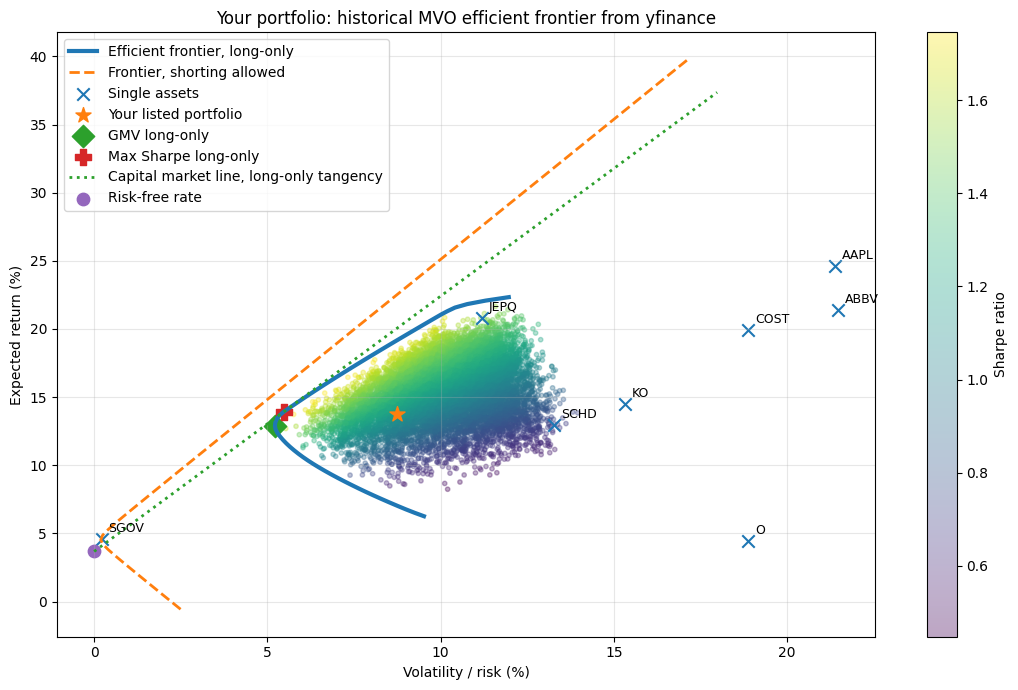

Summary metrics


,Portfolio,Return,Volatility,Variance,Sharpe
0,Your listed portfolio,13.75%,8.74%,0.007645,1.152
1,GMV long-only,12.92%,5.22%,0.002724,1.771
2,Max Sharpe long-only,13.92%,5.47%,0.002993,1.873
3,Risk-adjusted tau=1,22.48%,12.40%,0.015371,1.516
4,GMV unconstrained,4.55%,0.19%,0.000004,4.580
5,Max Sharpe unconstrained,4.73%,0.21%,0.000004,5.020


Weight comparison


,Your listed portfolio,GMV long-only,Max Sharpe long-only,Risk-adjusted tau=1
AAPL,8.76%,0.00%,2.22%,40.00%
ABBV,15.33%,5.26%,9.56%,24.14%
COST,3.28%,0.00%,2.73%,0.00%
JEPQ,5.77%,33.87%,37.53%,35.86%
KO,16.16%,13.88%,7.97%,0.00%
O,7.29%,0.00%,0.00%,0.00%
SCHD,21.47%,6.99%,0.00%,0.00%
SGOV,21.94%,40.00%,40.00%,0.00%


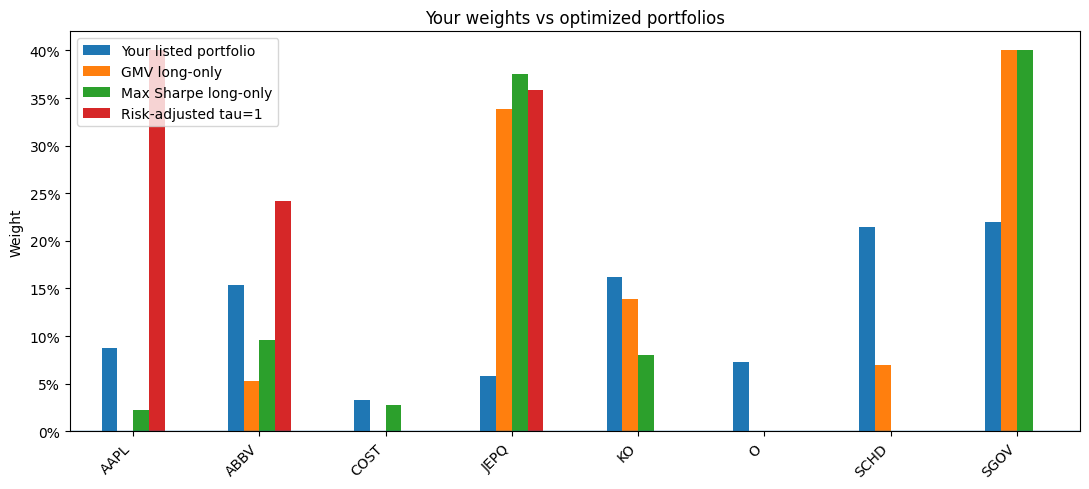

In [11]:
# ============================================================
# 6.4 Run MVO on your real portfolio
# ============================================================
if USE_YFINANCE:
    real_results = plot_efficient_frontier(
        mu_real, cov_real, aligned_tickers,
        rf=rf_annual,
        current_weights=current_weights_real.values,
        current_name="Your listed portfolio",
        title="Your portfolio: historical MVO efficient frontier from yfinance",
        n_random=12000,
        max_weight=MAX_WEIGHT,
    )

    print("Summary metrics")
    display(format_pct_table(real_results["summary"]))

    print("Weight comparison")
    display(real_results["weights"].map(lambda x: f"{x:.2%}"))

    plot_weights(real_results["weights"].to_dict(orient="series"), aligned_tickers, title="Your weights vs optimized portfolios")

## 7. How to analyze your portfolio result deeply

Use the output tables and charts above in this order:

### 1. Locate your portfolio on the frontier

If your portfolio dot is materially below the frontier, then using historical returns/covariances there was a portfolio with similar risk but higher expected return.

If it is near the frontier, your current mix was historically close to efficient.

### 2. Compare current portfolio vs GMV

The global minimum variance portfolio shows the lowest-risk long-only allocation under the current constraints.

For your portfolio, SGOV should usually reduce volatility because it behaves like a short-duration Treasury ETF. If the optimizer moves heavily toward SGOV, it means the historical covariance/return inputs prefer risk reduction over equity exposure.

### 3. Compare current portfolio vs max Sharpe

The max Sharpe portfolio maximizes expected excess return per unit of risk. It can be highly sensitive to the sample period. If one asset recently performed very well, the optimizer may over-allocate to it unless max-weight constraints are used.

### 4. Look at correlation, not only individual volatility

Diversification comes from covariance. Two assets can both be volatile, but if they are not perfectly correlated, portfolio volatility can be lower than a simple weighted average of individual volatilities.

### 5. Be careful with dividend/income ETFs

SCHD, JEPQ, O, and SGOV are income-oriented or rate-sensitive instruments. Historical adjusted close data usually attempts to include distributions, but check the exact data source before making real allocation decisions.

### 6. Do not blindly rebalance to the optimizer

Real-world frictions not included here:

- taxes
- transaction costs
- bid/ask spreads
- dividend preference
- liquidity
- concentration risk
- future return uncertainty
- income stability objectives
- personal risk tolerance

A practical use is: compare the optimizer with your current allocation and ask, “what risk is my portfolio taking, and is that risk intentional?”

## 8. Optional: CAPM, beta, and security market line using SPY

The method also covers CAPM: expected excess return should be proportional to market beta.

$$
E[r_i] - r_f = \beta_i\left(E[r_m] - r_f\right)
$$

where:

$$
\beta_i = \frac{\operatorname{cov}(r_i, r_m)}{\operatorname{var}(r_m)}
$$

This section estimates beta and alpha for each ticker relative to SPY.


,Beta,Realized annual return,CAPM expected return,Jensen alpha annual
Ticker,,,,
AAPL,0.89,24.63%,18.31%,6.52%
ABBV,0.11,21.39%,5.55%,17.10%
COST,0.63,19.95%,13.95%,6.20%
JEPQ,0.78,20.81%,16.44%,4.46%
KO,0.25,14.51%,7.69%,7.09%
O,0.61,4.48%,13.58%,-8.71%
SCHD,0.60,12.97%,13.43%,-0.43%
SGOV,0.00,4.56%,3.71%,0.92%


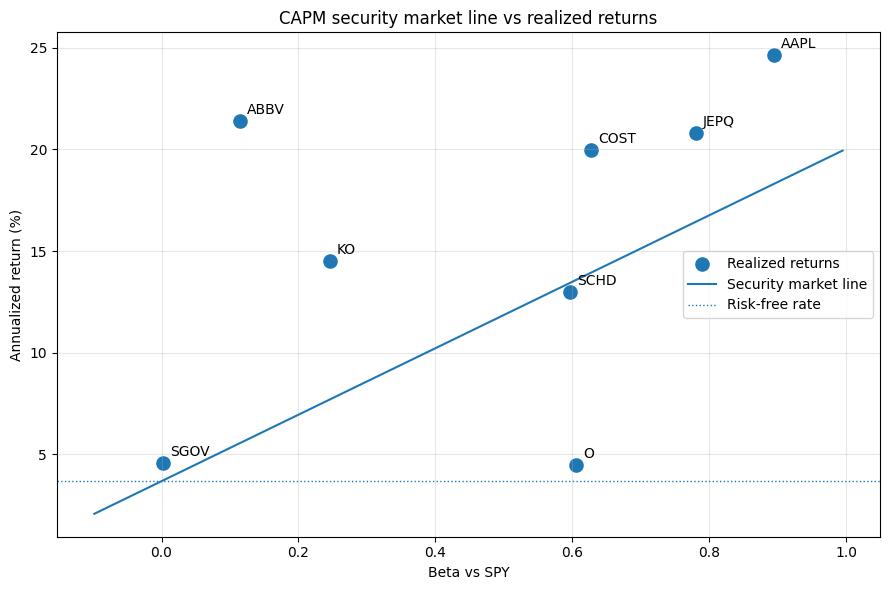

In [12]:
# ============================================================
# 8. CAPM / beta / alpha versus SPY
# ============================================================

def capm_beta_alpha(asset_returns, market_returns, rf_annual=0.04, periods_per_year=12):
    rf_period = (1 + rf_annual) ** (1 / periods_per_year) - 1
    market_excess = market_returns - rf_period
    rows = []
    for col in asset_returns.columns:
        asset_excess = asset_returns[col] - rf_period
        beta = asset_excess.cov(market_excess) / market_excess.var()
        alpha_period = asset_excess.mean() - beta * market_excess.mean()
        alpha_annual = (1 + alpha_period) ** periods_per_year - 1
        realized_return = asset_returns[col].mean() * periods_per_year
        capm_expected = rf_annual + beta * ((market_returns.mean() * periods_per_year) - rf_annual)
        rows.append({
            "Ticker": col,
            "Beta": beta,
            "Realized annual return": realized_return,
            "CAPM expected return": capm_expected,
            "Jensen alpha annual": alpha_annual,
        })
    return pd.DataFrame(rows).set_index("Ticker")

if USE_YFINANCE:
    market_ticker = "SPY"
    all_for_capm = aligned_tickers + [market_ticker]
    capm_prices = download_prices_yfinance(all_for_capm, start=START_DATE, end=END_DATE)
    capm_returns = prices_to_returns(capm_prices, freq=RETURN_FREQ)
    common_cols = [c for c in aligned_tickers if c in capm_returns.columns]

    capm_df = capm_beta_alpha(
        capm_returns[common_cols],
        capm_returns[market_ticker],
        rf_annual=rf_annual,
        periods_per_year=PERIODS_PER_YEAR,
    )

    display(capm_df.style.format({
        "Beta": "{:.2f}",
        "Realized annual return": "{:.2%}",
        "CAPM expected return": "{:.2%}",
        "Jensen alpha annual": "{:.2%}",
    }))

    # Security market line
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(capm_df["Beta"], capm_df["Realized annual return"] * 100, s=90, label="Realized returns")
    beta_line = np.linspace(capm_df["Beta"].min() - 0.1, capm_df["Beta"].max() + 0.1, 100)
    market_ann = capm_returns[market_ticker].mean() * PERIODS_PER_YEAR
    sml = rf_annual + beta_line * (market_ann - rf_annual)
    ax.plot(beta_line, sml * 100, label="Security market line")
    for ticker, row in capm_df.iterrows():
        ax.annotate(ticker, (row["Beta"], row["Realized annual return"] * 100), xytext=(5, 5), textcoords="offset points")
    ax.axhline(rf_annual * 100, linestyle=":", linewidth=1, label="Risk-free rate")
    ax.set_title("CAPM security market line vs realized returns")
    ax.set_xlabel("Beta vs SPY")
    ax.set_ylabel("Annualized return (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 9. Recommended real-world improvements

For a serious portfolio decision, extend this notebook with:

1. **Longer and shorter lookbacks**: compare 1Y, 3Y, 5Y where possible.
2. **Return assumptions override**: replace historical means with your forward-looking expected returns.
3. **Covariance shrinkage**: reduces overfitting to noisy correlations.
4. **Position caps**: e.g. no single asset above 25-40%.
5. **Turnover constraints**: do not rebalance too far from your current portfolio.
6. **Cash/Other bucket**: add your missing `Other` bucket explicitly as cash, SGOV, money market, or another ticker.
7. **Stress testing**: rising-rate scenario for O/JEPQ/SCHD; equity drawdown scenario for AAPL/COST/KO/ABBV.

The most useful practical question is not “what is the exact optimal weight?” but:

> Is my current portfolio below the historical efficient frontier, and which holdings are contributing most to return, volatility, and correlation?